### In this notebook, we will generate data similar to the "estimated risk" paper. 

BIO1 = Annual Mean Temperature

BIO2 = Mean Diurnal Range (Mean of monthly (max temp - min temp))

BIO3 = Isothermality (BIO2/BIO7) (×100)

BIO4 = Temperature Seasonality (standard deviation ×100)

BIO5 = Max Temperature of Warmest Month

BIO6 = Min Temperature of Coldest Month

BIO7 = Temperature Annual Range (BIO5-BIO6)

BIO8 = Mean Temperature of Wettest Quarter

BIO9 = Mean Temperature of Driest Quarter

BIO10 = Mean Temperature of Warmest Quarter

BIO11 = Mean Temperature of Coldest Quarter

BIO12 = Annual Precipitation

BIO13 = Precipitation of Wettest Month

BIO14 = Precipitation of Driest Month

BIO15 = Precipitation Seasonality (Coefficient of Variation)

BIO16 = Precipitation of Wettest Quarter

BIO17 = Precipitation of Driest Quarter

BIO18 = Precipitation of Warmest Quarter

BIO19 = Precipitation of Coldest Quarter

In [1]:
import rasterio
import pandas as pd
import numpy as np
from rasterio.transform import xy


# Define file paths
parent_dir = "./"
#parent_dir = "../../"
dir_world_clim = parent_dir + "world_clim/"
#dir_world_clim = parent_dir + "climate/world_clim/"
bio_folder = dir_world_clim
tavg_folder = dir_world_clim
#bio_folder = dir_world_clim + "wc2.1_30s_bio/"
#tavg_folder = dir_world_clim + "wc2.1_30s_tavg/"
ecdc_folder = parent_dir + ""
#ecdc_folder = "./"

In [2]:
presence_absence_file = ecdc_folder + '.albopictus_ecdc_as_WorldClim_raster.tif'  # filename of the presence absence raster
NUTS3_file = ecdc_folder + '.albopictus_ecdc_NUTS3_location_codes.tif'  # filename of the presence absence raster

tavg_tif_files = [tavg_folder + "wc2.1_30s_tavg_{month:02d}.tif".format(month=month) for month in range(1, 13)]

BIO_data = range(1,19) #[1, 5, 12, 18]

bio_data = [bio_folder + "wc2.1_30s_bio_{data:d}.tif".format(data=data) for data in BIO_data]



In [3]:
lookup_table = pd.read_csv(ecdc_folder + '.location_code_lookup.csv')


In [4]:
import rasterio
import pandas as pd
import numpy as np

# Function to extract coordinates only for the valid points
def get_masked_coordinates(transform, mask):
    indices = np.asarray(mask).nonzero()
    lons, lats = rasterio.transform.xy(transform, indices[0], indices[1])
    return np.array(lons), np.array(lats), indices

# Open the presence/absence raster
with rasterio.open(presence_absence_file) as src:
    presence_data = src.read(1)
    profile = src.profile
    presence_transform = src.transform
    presence_crs = src.crs
    height, width = src.height, src.width
    nodata_value = src.nodata
print(f"size of presence_data {presence_data.size}")
# Mask locations where presence_data is not 0, 1, 2, or 3
mask = presence_data < 4
print(f"number of true in mask {mask.sum()}")
# Get the coordinates only for masked points
lons, lats, indices = get_masked_coordinates(presence_transform, mask)
print("lat long created")

print(f"size of presence_data after mask {presence_data.size}")

# Load the NUTS3 lookup table
lookup_table = pd.read_csv(ecdc_folder + '.location_code_lookup.csv')
lookup_dict = dict(zip(lookup_table['RasterValue'], lookup_table['LocationCode']))

# Open the NUTS3 raster file and read the data
with rasterio.open(NUTS3_file) as nuts_src:
    nuts_data = nuts_src.read(1)
    nuts_transform = nuts_src.transform
    nuts_crs = nuts_src.crs

# Ensure that the NUTS3 raster aligns with the other rasters
assert nuts_src.height == height and nuts_src.width == width, "Dimensions mismatch in NUTS3 raster"
assert nuts_transform == presence_transform, "Transform mismatch in NUTS3 raster"
assert nuts_crs == presence_crs, "CRS mismatch in NUTS3 raster"

# Update the DataFrame with the Presence/Absence and coordinates data
df = pd.DataFrame({
    'Longitude': lons,
    'Latitude': lats,
    'Presence_Absence': presence_data[mask]
})

# Get the NUTS3 values for the masked points
nuts_values = nuts_data[mask]

# Map NUTS3 values to their LocationCode using the lookup table
df['NUTS3_Code'] = [lookup_dict.get(value, 'Unknown') for value in nuts_values]

print("DataFrame with NUTS3 codes created")

# Function to add raster data to the DataFrame
def add_raster_data_to_df(df, tif_files, column_prefix):
    for tif in tif_files:
        with rasterio.open(tif) as src:
            assert src.height == height and src.width == width, f"Dimensions mismatch in {tif}"
            assert src.transform == presence_transform, f"Transform mismatch in {tif}"
            assert src.crs == presence_crs, f"CRS mismatch in {tif}"
            
            data = src.read(1)
            df[f'{column_prefix}_{tif.split("_")[-1].split(".")[0]}'] = data[mask]
        print("read data from tif file", tif)
# Add temperature and BIO data to the DataFrame
add_raster_data_to_df(df, tavg_tif_files, 'TAVG')
add_raster_data_to_df(df, bio_data, 'BIO')

size of presence_data 933120000
number of true in mask 42813933
lat long created
size of presence_data after mask 933120000
DataFrame with NUTS3 codes created
read data from tif file ./world_clim/wc2.1_30s_tavg_01.tif
read data from tif file ./world_clim/wc2.1_30s_tavg_02.tif
read data from tif file ./world_clim/wc2.1_30s_tavg_03.tif
read data from tif file ./world_clim/wc2.1_30s_tavg_04.tif
read data from tif file ./world_clim/wc2.1_30s_tavg_05.tif
read data from tif file ./world_clim/wc2.1_30s_tavg_06.tif
read data from tif file ./world_clim/wc2.1_30s_tavg_07.tif
read data from tif file ./world_clim/wc2.1_30s_tavg_08.tif
read data from tif file ./world_clim/wc2.1_30s_tavg_09.tif
read data from tif file ./world_clim/wc2.1_30s_tavg_10.tif
read data from tif file ./world_clim/wc2.1_30s_tavg_11.tif
read data from tif file ./world_clim/wc2.1_30s_tavg_12.tif
read data from tif file ./world_clim/wc2.1_30s_bio_1.tif
read data from tif file ./world_clim/wc2.1_30s_bio_2.tif
read data from tif 

In [5]:
# Display the DataFrame
df

,Longitude,Latitude,Presence_Absence,NUTS3_Code,TAVG_01,TAVG_02,TAVG_03,TAVG_04,TAVG_05,TAVG_06,...,BIO_9,BIO_10,BIO_11,BIO_12,BIO_13,BIO_14,BIO_15,BIO_16,BIO_17,BIO_18
0,-33.770833,83.654167,0,GL,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,...,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38
1,-33.762500,83.654167,0,GL,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,...,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38
2,-33.754167,83.654167,0,GL,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,...,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38
3,-33.745833,83.654167,0,GL,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,...,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38
4,-33.737500,83.654167,0,GL,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,...,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42813928,55.654167,-21.387500,1,FRY40,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,...,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38
42813929,55.662500,-21.387500,1,FRY40,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,...,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38
42813930,55.670833,-21.387500,1,FRY40,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,...,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38
42813931,55.679167,-21.387500,1,FRY40,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,...,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38,-3.400000e+38


In [6]:
df.rename(columns={"BIO_1": "annual_temp", "BIO_5": "max_temp_warmest_month", "BIO_12": "annual_prec", "BIO_18": "prec_warmest_quarter"}, inplace=True)

In [7]:
df = df[df["annual_temp"] > -500]

In [8]:
import importlib
import aedes_suitability
importlib.reload(aedes_suitability)
from aedes_suitability import aedes_temperature_suitability_estimRisk

tavg = df[["TAVG_01", "TAVG_02", "TAVG_03", "TAVG_04", "TAVG_05", "TAVG_06", "TAVG_07", "TAVG_08", "TAVG_09", "TAVG_10", "TAVG_11", "TAVG_12"]].to_numpy()
df["Temperature Suitable"] = aedes_temperature_suitability_estimRisk(tavg)

/tmp/ipykernel_37072/1224789192.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Temperature Suitable"] = aedes_temperature_suitability_estimRisk(tavg)


In [9]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from aedes_suitability import aedes_precipitation_suitability

# Extract all temperature columns (TAVG_01 to TAVG_12) into a new DataFrame
# Apply the precipitation check using the limit_precipitation function with progress monitoring

df['Precipitation Suitable'] = aedes_precipitation_suitability(df['annual_prec'])

# Combine the precipitation and temperature suitability arrays to form the final suitability column
df['Suitable'] = np.logical_and(df['Precipitation Suitable'], df['Temperature Suitable'])

/tmp/ipykernel_37072/2644561675.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Precipitation Suitable'] = aedes_precipitation_suitability(df['annual_prec'])
/tmp/ipykernel_37072/2644561675.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Suitable'] = np.logical_and(df['Precipitation Suitable'], df['Temperature Suitable'])


<Axes: xlabel='Suitable'>

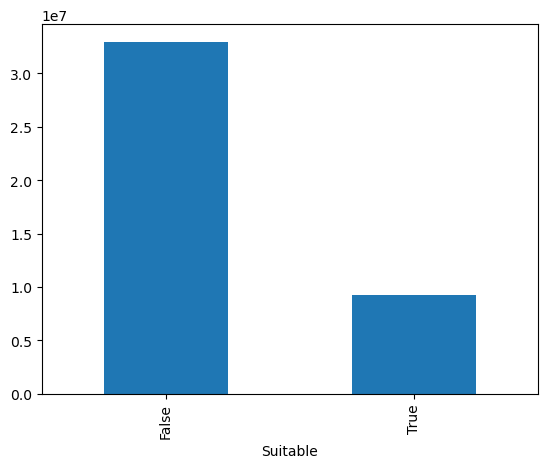

In [10]:
df["Suitable"].value_counts().plot(kind='bar')

In [11]:
df_aggregated = df.groupby([
    df['Latitude'].round(3),  # Higher precision for finer grid
    df['Longitude'].round(3)
]).Suitable.max().reset_index()


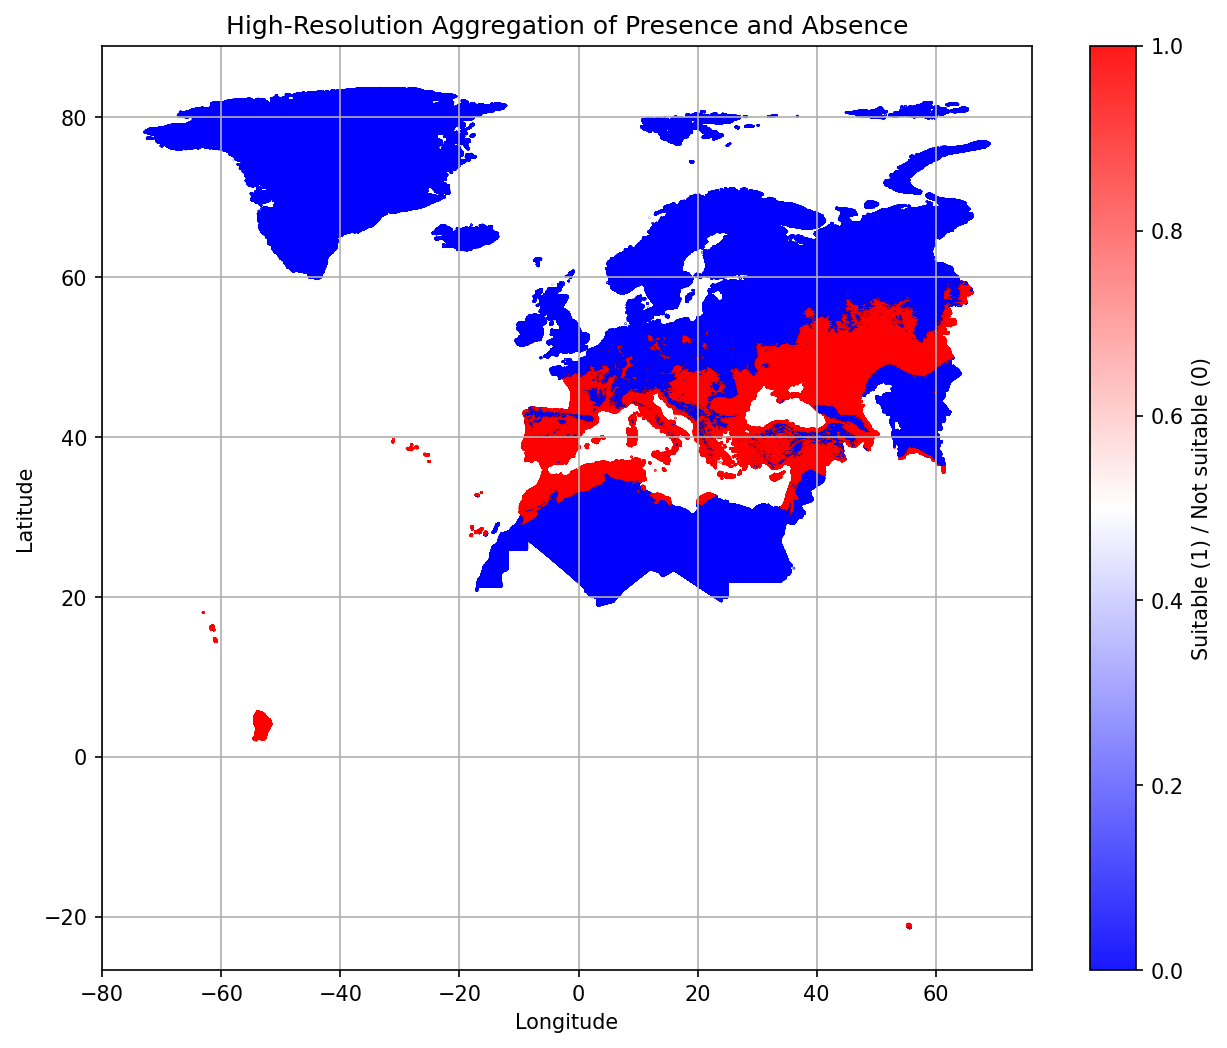

In [12]:
import matplotlib.pyplot as plt


# Generate a large, high-resolution scatter plot
plt.figure(figsize=(10, 8), dpi=150)  # Large figure with high DPI for quality
plt.scatter(
    df_aggregated['Longitude'], 
    df_aggregated['Latitude'], 
    c=df_aggregated['Suitable'], 
    cmap='bwr',  # Blue-White-Red, blue for absence, red for presence
    s=0.01,         # Small size for density
    alpha=0.9    # Transparency for overlapping points
)
plt.colorbar(label='Suitable (1) / Not suitable (0)')
plt.title('High-Resolution Aggregation of Presence and Absence')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)  # Add grid for easier geographic orientation
plt.show()


In [13]:
continental_european_country_codes = [
    'AL',  # Albania
    'AD',  # Andorra
    #'AM',  # Armenia
    'AT',  # Austria
    #'AZ',  # Azerbaijan
    'BY',  # Belarus
    'BE',  # Belgium
    'BA',  # Bosnia and Herzegovina
    'BG',  # Bulgaria
    'CH',  # Switzerland
    'CY',  # Cyprus
    'CZ',  # Czechia
    'DE',  # Germany
    'DK',  # Denmark
    'EE',  # Estonia
    'FI',  # Finland
    'FR',  # France
    #'GE',  # Georgia
    'GR',  # Greece
    'EL',  # Greece
    'HR',  # Croatia
    'HU',  # Hungary
    'IS',  # Iceland
    'IE',  # Ireland
    'IT',  # Italy
    #'KZ',  # Kazakhstan (European part)
    'XK',  # Kosovo
    'LI',  # Liechtenstein
    'LT',  # Lithuania
    'LU',  # Luxembourg
    'LV',  # Latvia
    'MC',  # Monaco
    'MD',  # Moldova
    'ME',  # Montenegro
    'MK',  # North Macedonia
    'MT',  # Malta
    'NL',  # Netherlands
    'NO',  # Norway
    'PL',  # Poland
    'PT',  # Portugal
    'RO',  # Romania
    #'RU',  # Russia (European part)
    'SM',  # San Marino
    'RS',  # Serbia
    'SK',  # Slovakia
    'SI',  # Slovenia
    'ES',  # Spain
    'SE',  # Sweden
    'CH',  # Switzerland
    #'TR',  # Turkey (European part)
    'UA',  # Ukraine
    'GB',  # United Kingdom
    'UK',  # United Kingdom
    'VA',  # Vatican City
]

# Code to filter the DataFrame for European NUTS3 codes with the valid country codes
df_european_nuts3 = df[df["NUTS3_Code"].str[:2].isin(continental_european_country_codes)]
df_european_nuts3 = df_european_nuts3[df_european_nuts3["Latitude"] > 34]
df_european_nuts3 = df_european_nuts3[df_european_nuts3["Latitude"] < 75]


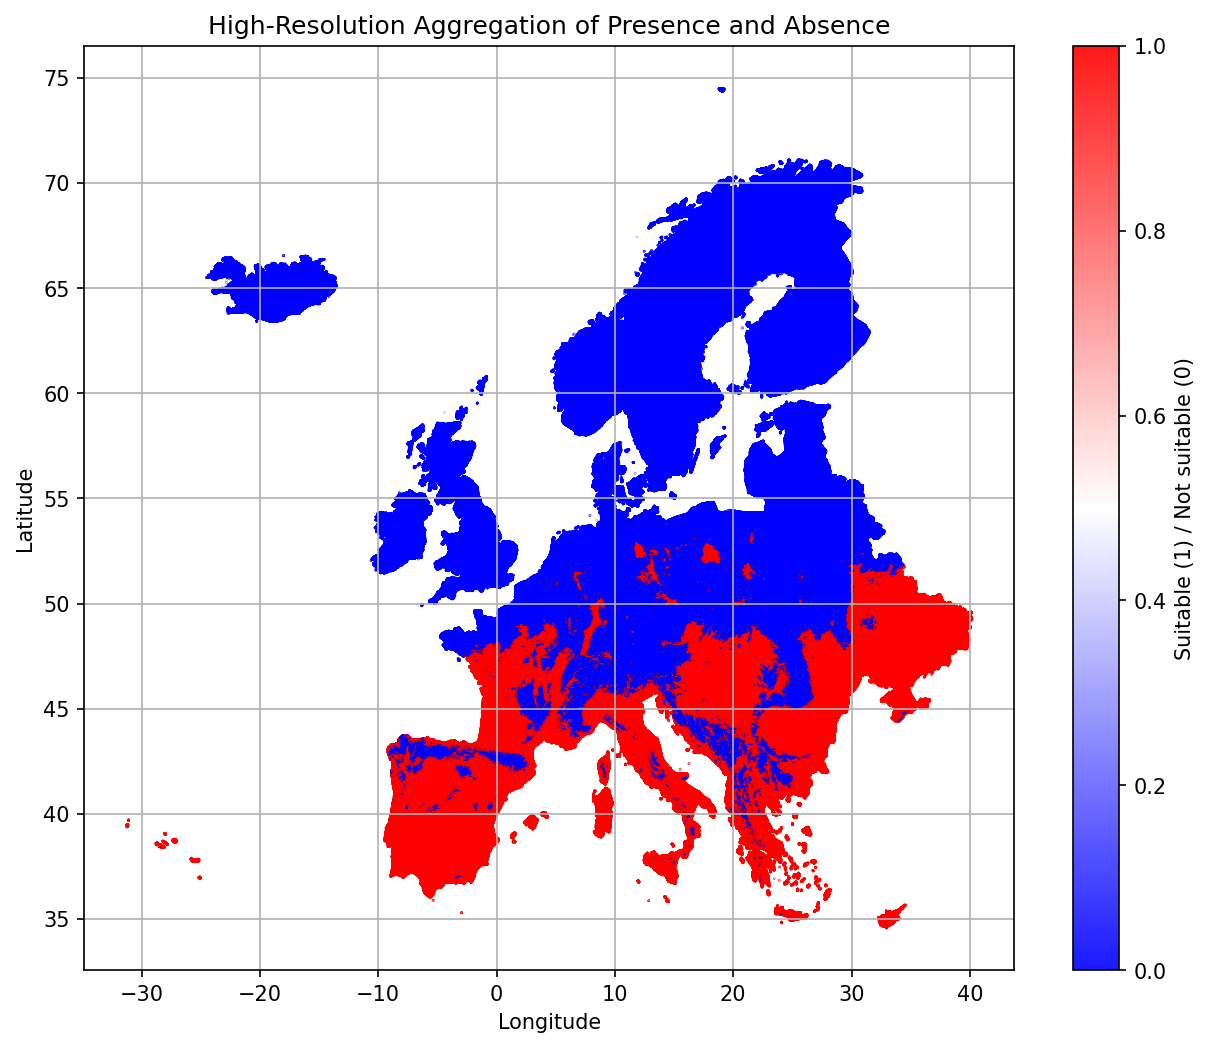

In [14]:
df_aggregated = df_european_nuts3.groupby([
    df_european_nuts3['Latitude'].round(3),  # Higher precision for finer grid
    df_european_nuts3['Longitude'].round(3)
]).Suitable.max().reset_index()
import matplotlib.pyplot as plt


# Generate a large, high-resolution scatter plot
plt.figure(figsize=(10, 8), dpi=150)  # Large figure with high DPI for quality
plt.scatter(
    df_aggregated['Longitude'], 
    df_aggregated['Latitude'], 
    c=df_aggregated['Suitable'], 
    cmap='bwr',  # Blue-White-Red, blue for absence, red for presence
    s=0.01,         # Small size for density
    alpha=0.9    # Transparency for overlapping points
)
plt.colorbar(label='Suitable (1) / Not suitable (0)')
plt.title('High-Resolution Aggregation of Presence and Absence')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)  # Add grid for easier geographic orientation
plt.show()


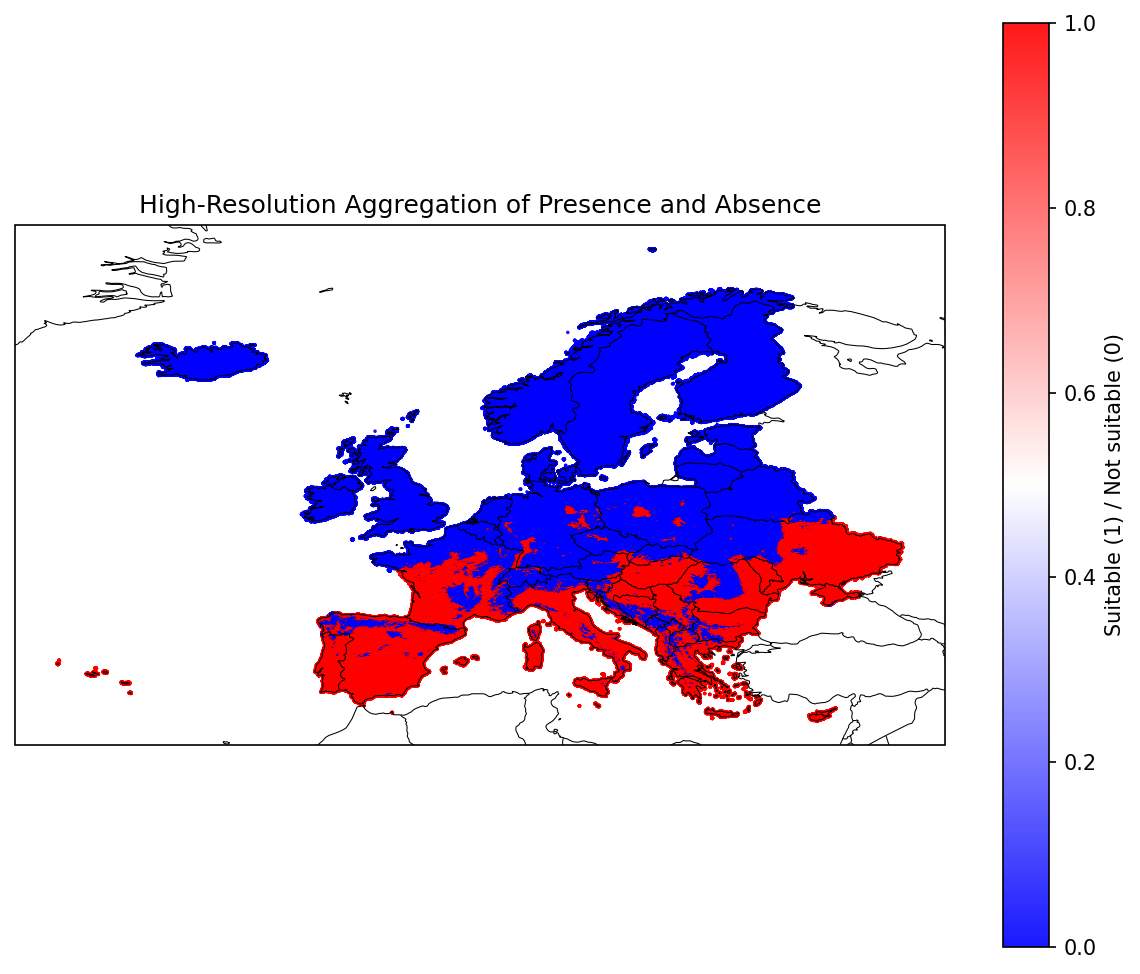

In [15]:

df_aggregated = df_european_nuts3.groupby([
    df_european_nuts3['Latitude'].round(3),  # Higher precision for finer grid
    df_european_nuts3['Longitude'].round(3)
]).Suitable.max().reset_index()
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Create a figure with a cartographic projection
fig = plt.figure(figsize=(10, 8), dpi=150)
ax = plt.axes(projection=ccrs.PlateCarree())

# Add country borders and coastlines
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

# Plot the data
sc = ax.scatter(
    df_aggregated['Longitude'],
    df_aggregated['Latitude'],
    c=df_aggregated['Suitable'],
    cmap='bwr',
    s=0.5,
    alpha=0.9,
    transform=ccrs.PlateCarree()
)

# Add a colorbar and titles
plt.colorbar(sc, label='Suitable (1) / Not suitable (0)')
plt.title('High-Resolution Aggregation of Presence and Absence')
plt.show()

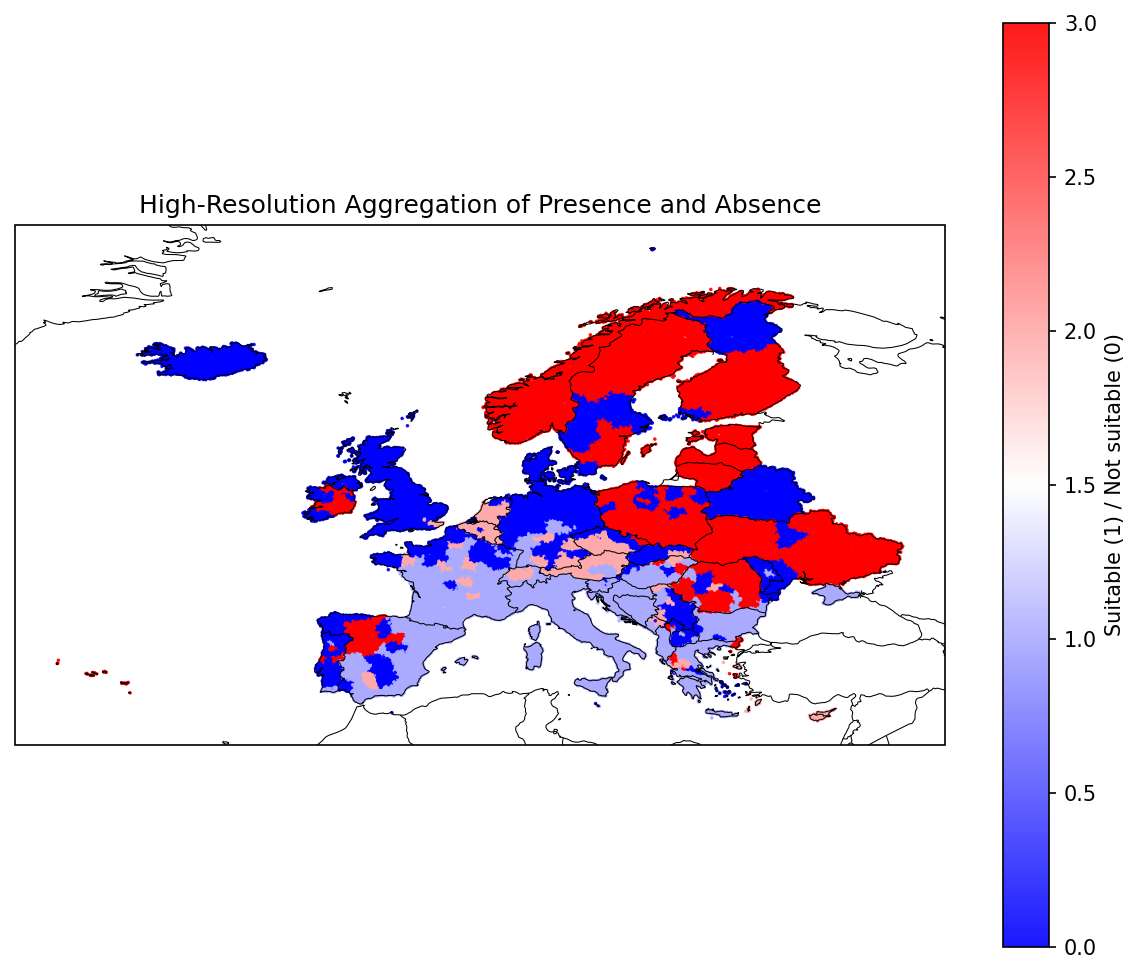

In [16]:

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Create a figure with a cartographic projection
fig = plt.figure(figsize=(10, 8), dpi=150)
ax = plt.axes(projection=ccrs.PlateCarree())
df_Presence_Absence_sampled = df_european_nuts3.sample(n=100000, random_state=1)
# Add country borders and coastlines
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

# Plot the data
sc = ax.scatter(
    df_Presence_Absence_sampled['Longitude'],
    df_Presence_Absence_sampled['Latitude'],
    c=df_Presence_Absence_sampled['Presence_Absence'],
    cmap='bwr',
    s=0.5,
    alpha=0.9,
    transform=ccrs.PlateCarree()
)

# Add a colorbar and titles
plt.colorbar(sc, label='Suitable (1) / Not suitable (0)')
plt.title('High-Resolution Aggregation of Presence and Absence')
plt.show()

In [17]:
df_european_nuts3.to_csv(ecdc_folder + "albopictus_presence_absence_ecdc_world_clim_all_bio.zip", index=False)

In [18]:
df_european_nuts3

,Longitude,Latitude,Presence_Absence,NUTS3_Code,TAVG_01,TAVG_02,TAVG_03,TAVG_04,TAVG_05,TAVG_06,...,annual_prec,BIO_13,BIO_14,BIO_15,BIO_16,BIO_17,prec_warmest_quarter,Temperature Suitable,Precipitation Suitable,Suitable
6130583,19.087500,74.512500,0,NO0B2,-7.2,-7.3,-6.2,-5.000000,-1.100000,2.300000,...,405.0,47.0,19.0,24.667305,125.0,66.0,103.0,False,True,False
6135461,18.937500,74.504167,0,NO0B2,-7.2,-7.3,-6.2,-4.900000,-1.000000,2.300000,...,402.0,47.0,19.0,25.584385,125.0,64.0,101.0,False,True,False
6135463,18.954167,74.504167,0,NO0B2,-7.3,-7.3,-6.2,-5.000000,-1.000000,2.300000,...,402.0,47.0,19.0,25.584385,125.0,64.0,101.0,False,True,False
6135464,18.962500,74.504167,0,NO0B2,-7.3,-7.3,-6.2,-4.900000,-1.000000,2.300000,...,401.0,47.0,19.0,25.464890,125.0,64.0,101.0,False,True,False
6135465,18.970833,74.504167,0,NO0B2,-7.3,-7.3,-6.2,-5.000000,-1.000000,2.300000,...,399.0,47.0,19.0,25.396273,125.0,64.0,101.0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35238584,32.937500,34.570833,2,CY00,12.4,12.7,14.2,17.400000,20.600000,24.200001,...,383.0,91.0,0.0,101.227264,240.0,4.0,4.0,True,True,True
35238585,32.945833,34.570833,2,CY00,12.4,12.6,14.2,17.299999,20.600000,24.200001,...,383.0,91.0,0.0,101.227264,240.0,4.0,4.0,True,True,True
35238586,32.954167,34.570833,2,CY00,12.4,12.6,14.2,17.299999,20.600000,24.200001,...,382.0,91.0,0.0,101.586967,240.0,4.0,4.0,True,True,True
35238587,32.962500,34.570833,2,CY00,12.4,12.6,14.2,17.400000,20.700001,24.200001,...,382.0,91.0,0.0,101.586967,240.0,4.0,4.0,True,True,True


In [19]:
df_european_nuts3

,Longitude,Latitude,Presence_Absence,NUTS3_Code,TAVG_01,TAVG_02,TAVG_03,TAVG_04,TAVG_05,TAVG_06,...,annual_prec,BIO_13,BIO_14,BIO_15,BIO_16,BIO_17,prec_warmest_quarter,Temperature Suitable,Precipitation Suitable,Suitable
6130583,19.087500,74.512500,0,NO0B2,-7.2,-7.3,-6.2,-5.000000,-1.100000,2.300000,...,405.0,47.0,19.0,24.667305,125.0,66.0,103.0,False,True,False
6135461,18.937500,74.504167,0,NO0B2,-7.2,-7.3,-6.2,-4.900000,-1.000000,2.300000,...,402.0,47.0,19.0,25.584385,125.0,64.0,101.0,False,True,False
6135463,18.954167,74.504167,0,NO0B2,-7.3,-7.3,-6.2,-5.000000,-1.000000,2.300000,...,402.0,47.0,19.0,25.584385,125.0,64.0,101.0,False,True,False
6135464,18.962500,74.504167,0,NO0B2,-7.3,-7.3,-6.2,-4.900000,-1.000000,2.300000,...,401.0,47.0,19.0,25.464890,125.0,64.0,101.0,False,True,False
6135465,18.970833,74.504167,0,NO0B2,-7.3,-7.3,-6.2,-5.000000,-1.000000,2.300000,...,399.0,47.0,19.0,25.396273,125.0,64.0,101.0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35238584,32.937500,34.570833,2,CY00,12.4,12.7,14.2,17.400000,20.600000,24.200001,...,383.0,91.0,0.0,101.227264,240.0,4.0,4.0,True,True,True
35238585,32.945833,34.570833,2,CY00,12.4,12.6,14.2,17.299999,20.600000,24.200001,...,383.0,91.0,0.0,101.227264,240.0,4.0,4.0,True,True,True
35238586,32.954167,34.570833,2,CY00,12.4,12.6,14.2,17.299999,20.600000,24.200001,...,382.0,91.0,0.0,101.586967,240.0,4.0,4.0,True,True,True
35238587,32.962500,34.570833,2,CY00,12.4,12.6,14.2,17.400000,20.700001,24.200001,...,382.0,91.0,0.0,101.586967,240.0,4.0,4.0,True,True,True


In [20]:
#df.to_parquet('albopictus_presence_absence_ecdc_world_clim.parquet', compression='brotli')  # Options: 'snappy', 'gzip', 'brotli'

In [21]:
df_european_nuts3.columns

Index(['Longitude', 'Latitude', 'Presence_Absence', 'NUTS3_Code', 'TAVG_01',
       'TAVG_02', 'TAVG_03', 'TAVG_04', 'TAVG_05', 'TAVG_06', 'TAVG_07',
       'TAVG_08', 'TAVG_09', 'TAVG_10', 'TAVG_11', 'TAVG_12', 'annual_temp',
       'BIO_2', 'BIO_3', 'BIO_4', 'max_temp_warmest_month', 'BIO_6', 'BIO_7',
       'BIO_8', 'BIO_9', 'BIO_10', 'BIO_11', 'annual_prec', 'BIO_13', 'BIO_14',
       'BIO_15', 'BIO_16', 'BIO_17', 'prec_warmest_quarter',
       'Temperature Suitable', 'Precipitation Suitable', 'Suitable'],
      dtype='object')